In [6]:
import numpy as np
import opendssdirect as dss
#-----
import yadi.dss.model as dss_model
import yadi.dss.sensitivity as dss_sens
import yadi.dss.qsts as dss_qsts
#-----
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.rc('text', usetex=True)
matplotlib.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb}')
sns.set_theme(context='paper',style='ticks')

In [7]:
cktfile = r"/home/sam/Research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS"
sens = dss_sens.DSS_Sensitivities(cktfile,verbose=False)
svp = sens.get_svp()
svq = sens.get_svq()
svp_total,svq_total=svp,svq

DSS Running file: /home/sam/Research/mohca_cl/mohca_cl/ga_tech/secondary/SecondaryTestCircuit_modified/Master.DSS
DSS Compiled Circuit: secondarytestcircuit


## Extract the slice indexes for the secondary subnetworks

In [8]:
def make_secondary_slices(n_secondaries = 12,include_lvxformers=False):
    """
    Make slices of the node indexes of the currently loaded opendss feeder mapping to the secondary networks
    Params:
        n_secondaries: Number of secondary groups in the feeder
        include_lvxformers: Include the low voltage transformer nodes in the list of secondary indexes
    """
    
    #Secondaries results dictionary
    secondaries = {}

    #Node names and node names by phase    
    node_names = dss.Circuit.AllNodeNames()
    a_node_names,b_node_names,c_node_names = dss.Circuit.AllNodeNamesByPhase(Phase=1),dss.Circuit.AllNodeNamesByPhase(Phase=2),dss.Circuit.AllNodeNamesByPhase(Phase=3)

    #Secondary indeces
    secondary_names = [str(i) for i in range(1,n_secondaries+1)] #Group index of the secondary names
    
    for sec_name in secondary_names:
        sec_bus_idx = 1 #Counter for the bus number within the secondary
        node_idxs_in_sec,node_names_in_sec = [],[] 
        
        for node_idx,node_name in enumerate(node_names):

            #Collect the phase info
            if(node_name in a_node_names):
                phase = 'a'
            elif(node_name in b_node_names):
                phase = 'b'
            elif(node_name in c_node_names):
                phase = 'c'
            else:
                print("no phase for: {node_name}".format(node_name=node_name))
                phase = ""

            if('sec' + sec_name + "_" in node_name): #Hacky way to separate by node name
                node_idxs_in_sec.append(node_idx)
                node_names_in_sec.append('s' + sec_name + "_" + str(sec_bus_idx) + "_"+phase)
                #Increment the secondary bus index counter
                sec_bus_idx += 1
            elif(include_lvxformers == True and ("trafo" + sec_name + "lv" in node_name)): #Catch low voltage transformers
                node_idxs_in_sec.append(node_idx)
                node_names_in_sec.append('s' + sec_name + "_" + "xfmrlv"+ "_"+phase)
        secondaries['sec' + sec_name] = {
            "node_idxs":node_idxs_in_sec,
            "node_names":node_names_in_sec
        }
    return secondaries         


## Item 2: Construct secondary matrices of varying topoologies FOR THE MODIFIED NETWORK

### Whether or not to include low voltage transformers

In [223]:
include_lv_xformers = False

In [224]:
secondaries = make_secondary_slices(include_lvxformers=include_lv_xformers)
secondaries

{'sec1': {'node_idxs': [46, 47, 48, 49, 50],
  'node_names': ['s1_1_a', 's1_2_a', 's1_3_a', 's1_4_a', 's1_5_a']},
 'sec2': {'node_idxs': [52], 'node_names': ['s2_1_b']},
 'sec3': {'node_idxs': [54, 55, 56, 57, 58],
  'node_names': ['s3_1_c', 's3_2_c', 's3_3_c', 's3_4_c', 's3_5_c']},
 'sec4': {'node_idxs': [60, 61, 62, 63, 64, 65],
  'node_names': ['s4_1_a', 's4_2_a', 's4_3_a', 's4_4_a', 's4_5_a', 's4_6_a']},
 'sec5': {'node_idxs': [67, 68, 69, 70, 71],
  'node_names': ['s5_1_c', 's5_2_c', 's5_3_c', 's5_4_c', 's5_5_c']},
 'sec6': {'node_idxs': [73, 74, 75, 76, 77, 78],
  'node_names': ['s6_1_c', 's6_2_c', 's6_3_c', 's6_4_c', 's6_5_c', 's6_6_c']},
 'sec7': {'node_idxs': [80, 81, 82, 83, 84, 85],
  'node_names': ['s7_1_a', 's7_2_a', 's7_3_a', 's7_4_a', 's7_5_a', 's7_6_a']},
 'sec8': {'node_idxs': [87, 88, 89, 90, 91, 92],
  'node_names': ['s8_1_b', 's8_2_b', 's8_3_b', 's8_4_b', 's8_5_b', 's8_6_b']},
 'sec9': {'node_idxs': [94, 95, 96],
  'node_names': ['s9_1_c', 's9_2_c', 's9_3_c']},
 'se

In [225]:
#Make secondary submatrices
import pandas as pd
secondaries = make_secondary_slices(include_lvxformers=include_lv_xformers)

#Note: hard code catch to catch the final subnetwork
names = dss.Circuit.AllNodeNames()
n_nodes = len(names)
sec_12_node_names = names[-14:]
n_nodes_sec_12 = len(sec_12_node_names)

sec_bus_idx = 1 #Counter for the bus number within the secondary
#Final sec12 network idxs
sec_12_node_idxs,formatted_sec_12_node_names = [],[]
for node_idx,node_name in enumerate(names):
    if(node_name in sec_12_node_names):
        sec_12_node_idxs.append(node_idx)
        if("xfmr" not in node_name):
            formatted_sec_12_node_names.append('s12_' + str(sec_bus_idx) + "_a")
            sec_bus_idx+=1
        else:
            formatted_sec_12_node_names.append("s12_xfmrlv_a")
secondaries["sec12"] = {
    'node_idxs':sec_12_node_idxs,
    'node_names':formatted_sec_12_node_names
}

In [226]:
def get_secondary_matrices(svp=svp,svq=svq):
    secs_svp,secs_svq = {},{} # secondary sensitivity matrices
    svp0,svq0 = svp['matrix'],svq['matrix']
    sec_names = list(secondaries.keys())
    for i,(sec_name,d) in enumerate(secondaries.items()):
        node_idxs = d["node_idxs"]
        node_names = d["node_names"]
        
        #Make the diagonal secondary sensitivity matrices
        s_svp = svp0[np.ix_(node_idxs,node_idxs)]
        s_svq = svq0[np.ix_(node_idxs,node_idxs)]

        #Make the off-diagonal secondary sensitivity matrices
        s_svp_offidag = {}
        s_svq_offidag = {}
        for j,(sec_name2,d2) in enumerate(secondaries.items()):
            if sec_name2 != sec_name:
                s_svp_offidag[sec_name2] = svp0[np.ix_(node_idxs,d2["node_idxs"])]
                s_svq_offidag[sec_name2] = svq0[np.ix_(node_idxs,d2["node_idxs"])]

        secs_svp[sec_name] = {
            "matrix":s_svp,
            "node_idxs":node_idxs,
            "node_names":node_names,
            "offidag":s_svp_offidag
        }
        secs_svq[sec_name] = {
            "matrix":s_svq,
            "node_idxs":node_idxs,
            "node_names":node_names,
            "offidag":s_svq_offidag
        }
    return secs_svp,secs_svq

In [227]:
secs_svp,secs_svq = get_secondary_matrices()

## Sufficient condition for invertibility test

In [228]:
def test_condition(sec_sens,s0):
    """
    Tests localiation condition given a dictionary of secondary sensitivity matrices
    and the full primary matrix.
    """
    is_localized = [] #List of booleans for localization condition
    values_row_localization = []
    values_col_localization = []
    for sec_name,d in sec_sens.items():
        s = d["matrix"] # for each secondary, compare with all other secondaries
        #print("sec: ",sec_name, " shape: ",s.shape)
        
        # chceck both row and column localization
        #NOTE: LOCALIZATION = 1 - SUM_{J != I}(NORM(S_II^{-1} S_IJ,2)))
        row_localization = 1
        col_localization = 1
        for other_sec_name,d_other in sec_sens.items():
            if(other_sec_name!=sec_name):
                idxs_other = d_other["node_idxs"]
                idxs_self = d["node_idxs"]
                dim_other = len(idxs_other)
                dim_self = len(idxs_self)

                # slice row blocks of the primary matrix s0
                s_other_row = np.zeros((dim_self,dim_other))
                s_other_row[:,:] = s0[np.ix_(idxs_self,idxs_other)]

                # slice column blocks of the primary matrix s0
                s_other_col = np.zeros((dim_self,dim_other))
                s_other_col[:,:] = s0.T[np.ix_(idxs_self,idxs_other)]

                # add to row_localization
                row_localization -= np.linalg.norm(np.linalg.inv(s)@s_other_row,ord=2)
                # add to col_localization
                col_localization -= np.linalg.norm(np.linalg.inv(s.T)@s_other_col,ord=2)

        #Check localization condition
        values_row_localization.append(row_localization)
        values_col_localization.append(col_localization)
        if(sum(values_row_localization)>0 or sum(values_col_localization)>0):
            is_localized.append(True)
        else:
            is_localized.append(False)

    return is_localized,values_row_localization,values_col_localization


In [229]:
is_localized_svp,values_rloc_svp,vals_cloc_svp = test_condition(secs_svp,svp["matrix"])
is_localized_svq,values_rloc_svq,vals_cloc_svq = test_condition(secs_svq,svq["matrix"])

(-0.35, 1.35)

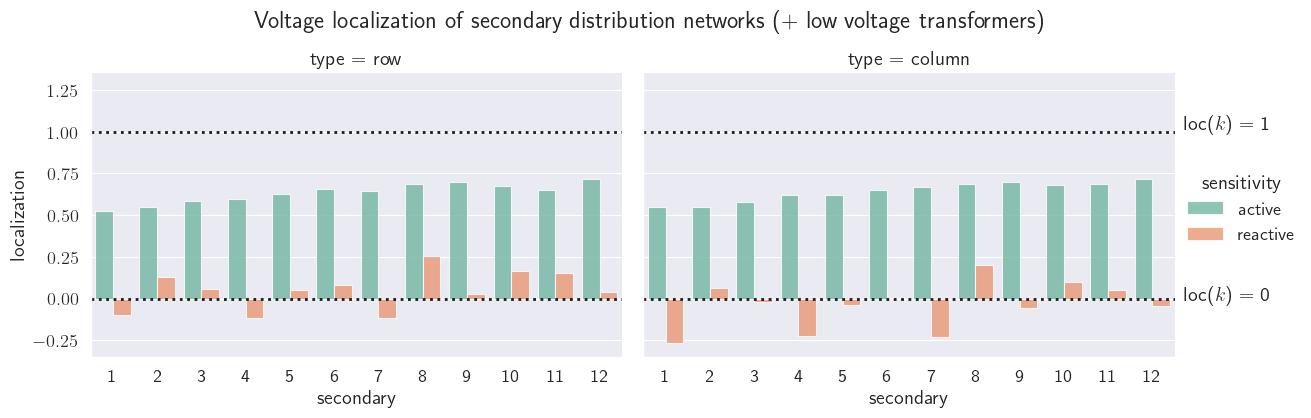

In [16]:
sns.set_theme(
    context='paper',
    style='darkgrid',
    font_scale=1.5

)
# make plotting dataframe via plotting dictionaries
pldf_dicts = [
    {
        "secondary":i+1,
        "localization":lvp,
        "sensitivity":'active',
        "type":"row"
    } for i,lvp in enumerate(values_rloc_svp) 
] + [
    {
        "secondary":i+1,
        "localization":lvp,
        "sensitivity":'active',
        "type":"column"
    } for i,lvp in enumerate(vals_cloc_svp)
] + [
    {
        "secondary":i+1,
        "localization":lvq,
        "sensitivity":'reactive',
        "type":"row"
    } for i,lvq in enumerate(values_rloc_svq)
] + [
    {
        "secondary":i+1,
        "localization":lvq,
        "sensitivity":"reactive",
        "type":"column"
    } for i,lvq in enumerate(vals_cloc_svq)
]
pldf = pd.DataFrame(pldf_dicts)


#plotting
#fig,axes = plt.subplots(1,2,figsize=(8.5,8.5/1.61828),constrained_layout=True,sharey=True)
G = sns.catplot(pldf,x="secondary",y="localization",hue="sensitivity",palette="Set2",col="type",kind="bar",alpha=0.8,height=4,aspect=1.5,legend_out=True)
G.axes[0,0].axhline(0.0,linestyle=':',color='k',label="loc($k$) = 0",lw=2)
G.axes[0,1].axhline(0.0,linestyle=':',color='k',lw=2)
G.axes[0,0].axhline(1.0,linestyle=':',color='k',label="loc($k$) = 1",lw=2)
G.axes[0,1].axhline(1.0,linestyle=':',color='k',lw=2)
#G.axes[0,0].annotate("Threshold",xy=(0.175,0.125),xycoords='axes fraction',ha='center')
G.axes[0,1].annotate("loc($k$) = 0",xy=(1.1,0.2),xycoords='axes fraction',ha='center')
G.axes[0,1].annotate("loc($k$) = 1",xy=(1.1,0.8),xycoords='axes fraction',ha='center')
#plt.fill_between([i for i in range(-1,13)],-0.35,0.0,color='k',alpha=0.1)
#plt.axhline(1.0,linestyle='--',color='k')
#plt.annotate("Threshold",xy=(0.175,0.85),xycoords='axes fraction',ha='center')
plt.suptitle("Voltage localization of secondary distribution networks (+ low voltage transformers)",y=1.05)
#plt.xlim()
plt.ylim(-0.35,1.35)
#plt.ylim(0,1.4)
#plt.savefig("figures/with_xfmrs_secondary_localization.pdf",bbox_inches="tight")

### Construct the matrices:

- Svp_blks : list of secondary submatrices
- Svp : full secondary matrix
- Svp_blkdiag: approximate secondary matrix considering only the diagonal blocks

In [230]:
from scipy.linalg import block_diag

start_idx = 45 #the index where the secondary nodes start

#voltage-active power
Svp = svp["matrix"][start_idx:,start_idx:]
Svp_blks = [secs_svp[sec_name]["matrix"] for sec_name in secondaries.keys()]
Svp_blkdiag = block_diag(*Svp_blks)

#voltage-reactive power
Svq = svq["matrix"][start_idx:,start_idx:]
Svq_blks = [secs_svq[sec_name]["matrix"] for sec_name in secondaries.keys()]
Svq_blkdiag = block_diag(*Svq_blks)


# Get the system of equations
p = len(Svp_blks) # number of secondaries
vdict = sens.get_node_voltages_mag_pu()
v = np.asarray([node_v for node_name,node_v in vdict.items()])[start_idx:] # voltage magnitudes

#Print shapes of each sens version
print("Svp shape: ",Svp.shape)
print("Svp_blks shape: ",[blk.shape for blk in Svp_blks])
print("Svp_blkdiag shape: ",Svp_blkdiag.shape)
print("v shape: ",v.shape)

Svp shape:  (73, 73)
Svp_blks shape:  [(5, 5), (1, 1), (5, 5), (6, 6), (5, 5), (6, 6), (6, 6), (6, 6), (3, 3), (3, 3), (2, 2), (14, 14)]
Svp_blkdiag shape:  (62, 62)
v shape:  (73,)


In [123]:
sens.get_node_base_voltages().values

array([26.55811238, 26.55811238, 26.55811238, 26.55811238, 26.55811238,
       26.55811238,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        7.19955786,  7.19955786,  7.19955786,  7.19955786,  7.19955786,
        0.24      ,  0.24      ,  0.24      ,  0.24      ,  0.24      ,
        0.24      ,  0.24      ,  0.24      ,  0.24      ,  0.24      ,
        0.24      ,  0.24      ,  0.24      ,  0.24      ,  0.24      ,
        0.24      ,  0.24      ,  0.24      ,  0.24      ,  0.24      ,
        0.24      ,  0.24      ,  0.24      ,  0.24      ,  0.24

### Solve the HC system

In [78]:
deltaV = np.random.randn(len(v)) # random perturbation in voltage
v_obs = v + deltaV # observed voltage
deltaX_true = np.linalg.inv(Svp)@(v_obs-v)
deltaX_blk = np.linalg.inv(Svp_blkdiag)@(v_obs-v)
print("Rel err: ", np.linalg.norm(deltaX_true-deltaX_blk)/np.linalg.norm(deltaX_true))
# deltaX_lr = blkdiag_low_rank_solve(Svp_blks,v_obs-v,[blk.shape[0]-1 for blk in Svp_blks])

Rel err:  0.006683785628772006


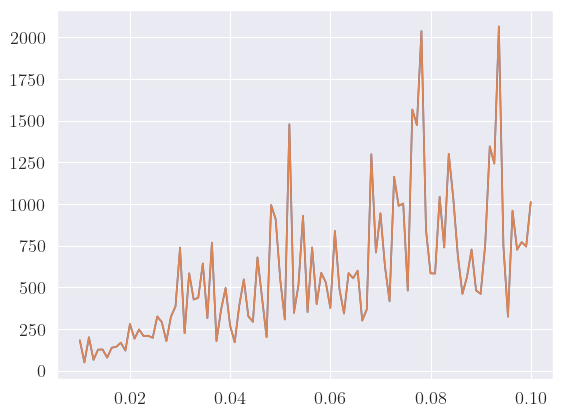

In [86]:
sigma_deltaV = 0.01
noise_sigma = np.linspace(0.01,0.1,100)
dense_rel_errs = []
blkdiag_rel_errs = []
for sigma in noise_sigma:
    # a "ground truth" perturbation in voltage, and the corresponding injection change.
    v_obs_true = v + sigma_deltaV*np.random.randn(len(v)) # observed voltage
    deltaX_true = np.linalg.inv(Svp)@(v_obs_true-v)

    # Observed voltage with noise
    v_obs = v_obs_true + sigma*np.random.randn(len(v)) # observed voltage
    hat_deltaX = np.linalg.inv(Svp)@(v_obs-v)
    hat_deltaX_blk = np.linalg.inv(Svp_blkdiag)@(v_obs-v)
    
    blkdiag_rel_errs.append(np.linalg.norm(deltaX_true-hat_deltaX_blk)/np.linalg.norm(deltaX_true)*100)
    dense_rel_errs.append(np.linalg.norm(deltaX_true-hat_deltaX)/np.linalg.norm(deltaX_true)*100)
plt.plot(noise_sigma,dense_rel_errs,label="dense")
plt.plot(noise_sigma,blkdiag_rel_errs,label="blkdiag")

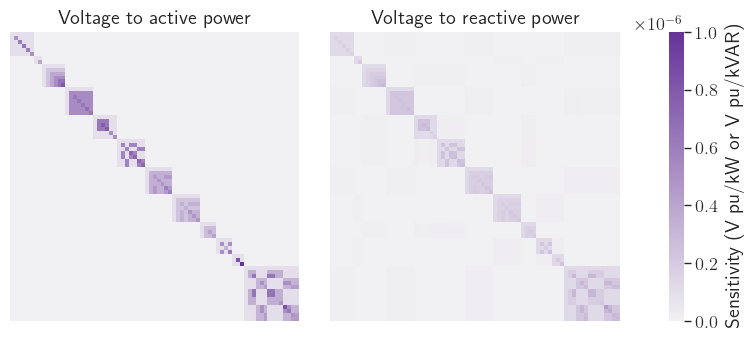

In [124]:
fig,axes = plt.subplots(ncols=2,figsize=(7.5,8/1.61828/1.5),constrained_layout=True)
cm = sns.light_palette("rebeccapurple",as_cmap=True)
sns.heatmap(Svp,xticklabels=False,yticklabels=False,cmap=cm,ax=axes[0],vmin=0.0,vmax=1e-6,square=True,cbar=False,rasterized=True)
sns.heatmap(Svq,xticklabels=False,yticklabels=False,cmap=cm,ax=axes[1],vmin=0.0,vmax=1e-6,square=True,cbar_kws={"label":"Sensitivity (V pu/kW or V pu/kVAR)"},rasterized=True)

#titles
axes[0].set_title("Voltage to active power")#set_title("$\partial v / \partial p$")
axes[1].set_title("Voltage to reactive power")#set_title("$\partial v / \partial q$")
plt.savefig("figures/sensitivity_matrices.pdf",bbox_inches="tight")

## Analyzing Localization
- Plot the localization as a function of the number of secondary networks.
- At each iteration, select a random secondary network out of the 12 basecase secondary networks.
- Append the new secondary network to the list of secondary networks.
- Create a new block-diagonally DOMINANT dense sensitivity matrix by appending the new secondary network to the diagonal AS WELL AS the off-diagonal blocks.
- Compute the localization of the new block diagonally DOMINANT dense sensitivity matrix.

In [147]:
# # Compute the mean and standard deviation of the off-diagonal entries of the basecase dense sensitivity matrix.
# # We will use this to generate random off-diagonal matrices with the same mean and standard deviation.
# # This is a hacky way to generate random matrices with the same "structure" as the basecase matrix.
# sec1_idx = secondaries["sec1"]["node_idxs"]
# mean_svp_offdiag = np.mean(Svp[np.ix_(sec1_idx,[i for i in range(len(Svp)) if i not in sec1_idx])])
# std_svp_offdiag = np.std(Svp[np.ix_(sec1_idx,[i for i in range(len(Svp)) if i not in sec1_idx])])
# mean_svq_offdiag = np.mean(Svq[np.ix_(sec1_idx,[i for i in range(len(Svq)) if i not in sec1_idx])])
# std_svq_offdiag = np.std(Svq[np.ix_(sec1_idx,[i for i in range(len(Svq)) if i not in sec1_idx])])
# print("mean_svp_offdiag: ",mean_svp_offdiag)
# print("std_svp_offdiag: ",std_svp_offdiag)
# print("mean_svq_offdiag: ",mean_svq_offdiag)
# print("std_svq_offdiag: ",std_svq_offdiag)

mean_svp_offdiag:  8.789578327903182e-09
std_svp_offdiag:  4.584772134030163e-08
mean_svq_offdiag:  9.52870301166016e-09
std_svq_offdiag:  3.0025719537826204e-08


In [231]:
# List of secondary names, which we will ranodm select at each iteration
sec_names = [sec_name for sec_name in secondaries.keys()]
n_base_sec = 12 # total number of base case secondaries
max_sec = 200 # maximum number of secondaries to test

#Compute the base case localization values
_,base_svp_localization,_ = test_condition(secs_svp,svp["matrix"]) 
_,base_svq_localization,_ = test_condition(secs_svq,svq["matrix"])
active_localization,reactive_localization = np.zeros((max_sec+12,n_base_sec)),np.zeros((max_sec,n_base_sec)) # localization matrix, each column is a base case secondary

active_localization[0,:],reactive_localization[0,:] = np.ones(n_base_sec),np.ones(n_base_sec)

#Initalize the localization matrix with the base case localization values. 
for j,sec in enumerate(sec_names):
    diag_svp = secs_svp[sec]["matrix"]
    diag_svq = secs_svq[sec]["matrix"]
    off_diag_svp = secs_svp[sec]["offidag"]
    off_diag_svq = secs_svq[sec]["offidag"]
    iter = 1
    for name_other_sec in sec_names:
        if name_other_sec != sec:
            active_localization[iter,j] = active_localization[iter-1,j]  - np.linalg.norm(np.linalg.inv(diag_svp)@off_diag_svp[name_other_sec],ord=2)
            reactive_localization[iter,j] = reactive_localization[iter-1,j] - np.linalg.norm(np.linalg.inv(diag_svq)@off_diag_svq[name_other_sec],ord=2)
            iter+=1
        else:
            continue

active_localization[12,:],reactive_localization[12,:] = base_svp_localization,base_svq_localization


for kth_new_sec in range(12,max_sec):

    # Sample one of the secondary names
    name_new_sec = np.random.choice(sec_names) #the selected secondard
    dim_new_sec = len(secondaries[name_new_sec]["node_idxs"]) # number of nodes in this secondary randomly selected secondary
    idxs_new_sec = secondaries[name_new_sec]["node_idxs"] # node indexes of the randomly selected secondary

    # #Get the off diagonal matrices for the new secondary
    # offdiags_svp = secs_svp[name_new_sec]["offidag"]
    # offdiags_svq = secs_svq[name_new_sec]["offidag"]

    for i,name_other_sec in enumerate(sec_names):
        other_sec_Svp = secs_svp[name_other_sec]["matrix"] # sensitivity matrix for this secondary
        other_sec_Svq = secs_svq[name_other_sec]["matrix"] # sensitivity matrix for this secondary
        if name_other_sec != name_new_sec:
            #Get the off diagonal matrices for the other secondary
            
            offdiag_svp = secs_svp[name_other_sec]["offidag"][name_new_sec]
            offdiag_svq = secs_svq[name_other_sec]["offidag"][name_new_sec]
            
           # mean_svp_offdiag = np.mean([np.mean(secs_svp["name_other_sec"]["offidag"][name]) for ])
            #offdiag_svp = np.random.normal(mean_svp_offdiag,std_svp_offdiag,(sec_Svp.shape[0],dim_new_sec))
          #  offdiag_svq = np.random.normal(mean_svq_offdiag,std_svq_offdiag,(sec_Svq.shape[0],dim_new_sec))


            #print shapes
            print("other_sec: ",name_other_sec, " shape: ",other_sec_Svp.shape)
            print("other_sec: ",name_other_sec, " shape: ",other_sec_Svq.shape)
            print("new_offdiag: ",name_new_sec, " shape: ",offdiag_svp.shape)
            print("new_offdiag: ",name_new_sec, " shape: ",offdiag_svq.shape)

            #Update the localization values
            active_localization[kth_new_sec,i] = active_localization[kth_new_sec-1,i] - np.linalg.norm(np.linalg.inv(other_sec_Svp)@offdiag_svp,ord=2)
            reactive_localization[kth_new_sec,i] = reactive_localization[kth_new_sec-1,i] - np.linalg.norm(np.linalg.inv(other_sec_Svq)@offdiag_svq,ord=2)
        else:
            active_localization[kth_new_sec,i] = active_localization[kth_new_sec-1,i]
            reactive_localization[kth_new_sec,i] = reactive_localization[kth_new_sec-1,i]

    


    # # Iterate through each base case secondary, and update their localization values
    # for i,(name_other_sec,sec_dict) in enumerate(secondaries.items()):

    #     other_idxs = sec_dict["node_idxs"] # node indexes of the base case secondary
    #     dim_other = len(other_idxs) # number of nodes in the base case secondary
    #     sec_Svp = secs_svp[name_other_sec]["matrix"] # sensitivity matrix for this secondary
    #     sec_Svq = secs_svq[name_other_sec]["matrix"] # sensitivity matrix for this secondary

    #     # Generate new off-diagonal blocks to be used to update the localization values
    #     # slice row blocks of the primary matrix s0
    #     svp_offdiag,svq_offdiag = np.zeros((dim_other,dim_new_sec)),np.zeros((dim_other,dim_new_sec))
    #     #print("svp_offdiag shape: ",svp_offdiag.shape)
    #     #print("svq_offdiag shape: ",svq_offdiag.shape)
    #     svp_offdiag[:,:] = svp_total["matrix"][np.ix_(other_idxs,idxs_new_sec)]
    #     svq_offdiag[:,:] = svq_total["matrix"][np.ix_(other_idxs,idxs_new_sec)]

    #     #svp_offdiag = np.random.normal(mean_svp_offdiag,std_svp_offdiag,(sec_Svp.shape[0],dim_new_sec))
    #     #svq_offdiag = np.random.normal(mean_svq_offdiag,std_svq_offdiag,(sec_Svq.shape[0],dim_new_sec))

    #     print("sec: ",name_other_sec, " shape: ",sec_Svp.shape)
    #     print("sec: ",name_other_sec, " shape: ",sec_Svq.shape)
    #     print("new_offdiag: ",name_new_sec, " shape: ",svp_offdiag.shape)
    #     print("new_offdiag: ",name_new_sec, " shape: ",svp_offdiag.shape)
        
    #     active_localization[kth_new_sec,i] = active_localization[kth_new_sec-1,i] - np.linalg.norm(np.linalg.inv(sec_Svp)@svp_offdiag,ord=2)
    #     reactive_localization[kth_new_sec,i] = reactive_localization[kth_new_sec-1,i] - np.linalg.norm(np.linalg.inv(sec_Svq)@svq_offdiag,ord=2)

    
    

other_sec:  sec1  shape:  (5, 5)
other_sec:  sec1  shape:  (5, 5)
new_offdiag:  sec12  shape:  (5, 14)
new_offdiag:  sec12  shape:  (5, 14)
other_sec:  sec2  shape:  (1, 1)
other_sec:  sec2  shape:  (1, 1)
new_offdiag:  sec12  shape:  (1, 14)
new_offdiag:  sec12  shape:  (1, 14)
other_sec:  sec3  shape:  (5, 5)
other_sec:  sec3  shape:  (5, 5)
new_offdiag:  sec12  shape:  (5, 14)
new_offdiag:  sec12  shape:  (5, 14)
other_sec:  sec4  shape:  (6, 6)
other_sec:  sec4  shape:  (6, 6)
new_offdiag:  sec12  shape:  (6, 14)
new_offdiag:  sec12  shape:  (6, 14)
other_sec:  sec5  shape:  (5, 5)
other_sec:  sec5  shape:  (5, 5)
new_offdiag:  sec12  shape:  (5, 14)
new_offdiag:  sec12  shape:  (5, 14)
other_sec:  sec6  shape:  (6, 6)
other_sec:  sec6  shape:  (6, 6)
new_offdiag:  sec12  shape:  (6, 14)
new_offdiag:  sec12  shape:  (6, 14)
other_sec:  sec7  shape:  (6, 6)
other_sec:  sec7  shape:  (6, 6)
new_offdiag:  sec12  shape:  (6, 14)
new_offdiag:  sec12  shape:  (6, 14)
other_sec:  sec8  sh

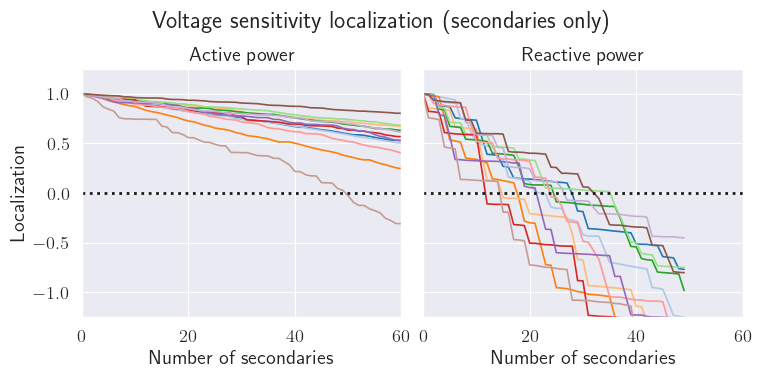

In [235]:
fig,axes = plt.subplots(ncols=2,figsize=(7.5,8/1.61828/1.5),constrained_layout=True,sharey=True)

colors = sns.color_palette("tab20",n_colors=12)
for i in range(12):
    axes[0].plot(active_localization[:80,i],label=str(i+1),color=colors[i])
#axes[0].legend(title="Secondary",ncols=3)
axes[0].set_title("Active power")
axes[0].set_xlabel("Number of secondaries")
axes[0].set_ylabel("Localization")

for i in range(12):
    axes[1].plot(reactive_localization[:50,i],label=str(i+1),color=colors[i])
axes[1].set_title("Reactive power")
axes[1].set_xlabel("Number of secondaries")
axes[1].set_xlim(0,60)
axes[0].set_xlim(0,60)
axes[1].set_ylim(-1.25,1.25)
axes[0].axhline(0.0,linestyle=':',color='k',lw=2)
axes[1].axhline(0.0,linestyle=':',color='k',lw=2)
plt.suptitle("Voltage sensitivity localization (secondaries only)",y=1.1)


plt.savefig("figures/no_xfmrs_localization.pdf",bbox_inches="tight")

#sns.move_legend(axes[0],loc="lower center",bbox_to_anchor=(0.5,1.1),ncol=6)



#plt.plot(active_localization[0:30,:])

In [96]:
 secs_svp["sec1"]

{'matrix': array([[9.14575942e-08, 9.15988536e-08, 9.16497883e-08, 9.16739870e-08,
         9.16395323e-08, 9.15891569e-08],
        [9.22084629e-08, 5.15006419e-07, 9.24022324e-08, 9.24266298e-08,
         9.23918917e-08, 9.23411028e-08],
        [9.23650626e-08, 9.25077203e-08, 6.05827883e-07, 9.25835992e-08,
         9.25488021e-08, 9.24979268e-08],
        [9.24706778e-08, 9.26134980e-08, 9.26649970e-08, 6.66376966e-07,
         9.26546267e-08, 9.26036933e-08],
        [9.23699820e-08, 9.25126472e-08, 9.25640901e-08, 9.25885302e-08,
         6.05799033e-07, 9.25028533e-08],
        [9.22138447e-08, 9.23562696e-08, 9.24076254e-08, 9.24320243e-08,
         9.23972842e-08, 5.14981250e-07]]),
 'node_idxs': [45, 46, 47, 48, 49, 50],
 'node_names': ['s1_xfmrlv_a',
  's1_1_a',
  's1_2_a',
  's1_3_a',
  's1_4_a',
  's1_5_a']}

In [95]:
b

'node_idxs'

## Spectral Analysis Plots

In [277]:
### Spectral Analysis
def spectral_analysis(S):
    """Computes normalized and commulative spectral analysis for a given matrix with the SVD"""
    u,sigma,vt = np.linalg.svd(S)
    sigma_total = np.sum(sigma)
    normed_sigma = sigma/sigma_total
    cum_sigma = np.cumsum(normed_sigma)
    return cum_sigma,normed_sigma

def plot_spectral_analysis(S):
    """Plots the normalized and cummulative spectral analysis for a given matrix S"""
    cum_sigma,normed_sigma = spectral_analysis(S)
    fig,axes = plt.subplots(constrained_layout=True,figsize=(3.5*2,3.5*2/1.61828),ncols=2)
    axes[0].plot(normed_sigma,'o')
    axes[1].plot(cum_sigma,'o')
    axes[0].set_title('Normalized Singular Values')
    axes[1].set_title('Cumulative Singular Values')
    axes[0].set_xlabel('Singular Value Index')
    axes[1].set_xlabel('Singular Value Index')
    axes[0].set_ylabel('Normalized Singular Value')
    axes[1].set_ylabel('Cumulative Singular Value')
    return fig,axes


sec1 (6, 6)
sec1 largest svdval:  2.411373960232624e-06
sec2 (2, 2)
sec2 largest svdval:  1.0152494843923209e-06
sec3 (6, 6)
sec3 largest svdval:  5.347146525965303e-06
sec4 (7, 7)
sec4 largest svdval:  7.91759545780433e-06
sec5 (6, 6)
sec5 largest svdval:  4.942052283411082e-06
sec6 (7, 7)
sec6 largest svdval:  5.157517779985251e-06
sec7 (7, 7)
sec7 largest svdval:  5.611646600256001e-06
sec8 (7, 7)
sec8 largest svdval:  4.408290301988359e-06
sec9 (4, 4)
sec9 largest svdval:  2.3008034898680414e-06
sec10 (4, 4)
sec10 largest svdval:  2.728577376091834e-06
sec11 (3, 3)
sec11 largest svdval:  2.765069183240011e-06
sec12 (14, 14)
sec12 largest svdval:  8.116890173025158e-06


Text(0, 0.5, 'Cumulative Singular Value')

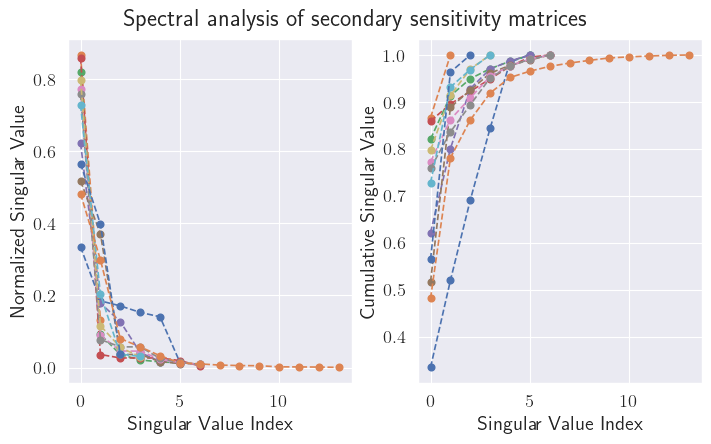

In [281]:
fig,axes = plt.subplots(constrained_layout=True,figsize=(3.5*2,3.5*2/1.61828),ncols=2)
for sec_name,d in secs_svp.items():
    print(sec_name,d["matrix"].shape)
    print(sec_name,"largest svdval: ",np.linalg.norm(d["matrix"],ord=2))
    m = d["matrix"]
    csig,nsig = spectral_analysis(m) #cumulative and normalized singular values
    axes[0].plot(nsig,'--o',label=sec_name)
    axes[1].plot(csig,'--o',label=sec_name)
#axes[0].set_title('Normalized Singular Values')
#axes[1].set_title('Cumulative Singular Values')
plt.suptitle("Spectral analysis of secondary sensitivity matrices")
axes[0].set_xlabel('Singular Value Index')
axes[1].set_xlabel('Singular Value Index')
axes[0].set_ylabel('Normalized Singular Value')
axes[1].set_ylabel('Cumulative Singular Value')


In [ ]:
FOR